In [1]:
# Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os
import matplotlib.pyplot as plt
import tifffile as tiff
from torchvision import transforms
from PIL import Image


In [37]:
import numpy as np

In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:

# -----------------------
# Dataset definition
# -----------------------
class TestDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # Make sure images and masks are sorted similarly
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.tif') or f.endswith('.png')])
        self.mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.tif') or f.endswith('.png')])
        assert len(self.img_files) == len(self.mask_files), "Number of images and masks should be equal"
    
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        
        # Load images using tifffile for 16-bit preservation
        img = tiff.imread(img_path).astype(np.float32)
        mask = tiff.imread(mask_path).astype(np.float32)
        
        # Normalize image like training
        img = img / img.max()
        mask = (mask > 0).astype(np.float32)
        
        # Convert to tensors
        img = torch.from_numpy(img).unsqueeze(0)  # [1,H,W]
        mask = torch.from_numpy(mask).unsqueeze(0)
        
        return img, mask

In [22]:
# -----------------------
# Transform
# -----------------------
transform = transforms.Compose([
    transforms.ToTensor(),  # convert to [0,1] tensor
])

In [40]:
# -----------------------
# Load dataset
# -----------------------
test_img_dir = "./datas/original/test/imgs"

test_mask_dir = "./datas/original/test/labels"

test_ds = TestDataset(test_img_dir, test_mask_dir)


In [ ]:
# -----------------------
# Load model
# -----------------------
from models.baseline_Unet_ViT import U_net_ViT  # <- adjust import

model = U_net_ViT(
    encode_in=(1, 64, 128, 256),
    encode_out=(64, 128, 256, 512),
    decode_in=(1024, 512, 256, 128),
    decode_out=(512, 256, 128, 64),
    normalize=True
) # create model instance
model.load_state_dict(torch.load("./models/predicted_models/unet_vit_trained.pth", map_location=device))
model.to(device)
model.eval()

U_net_ViT(
  (encode): ModuleList(
    (0): EncodeBlock(
      (conv_block): Convblock(
        (p1): PrintSize()
        (p2): PrintSize()
        (p3): PrintSize()
        (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
        (bNorm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (bNorm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (dropout): Dropout2d(p=0.2, inplace=False)
        (activation): ReLU(inplace=True)
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncodeBlock(
      (conv_block): Convblock(
        (p1): PrintSize()
        (p2): PrintSize()
        (p3): PrintSize()
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
        (bNorm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (con

Size: torch.Size([1, 1, 768, 768])
Size: torch.Size([1, 64, 766, 766])
Size: torch.Size([1, 64, 764, 764])
Size: torch.Size([1, 64, 382, 382])
Size: torch.Size([1, 128, 380, 380])
Size: torch.Size([1, 128, 378, 378])
Size: torch.Size([1, 128, 189, 189])
Size: torch.Size([1, 256, 187, 187])
Size: torch.Size([1, 256, 185, 185])
Size: torch.Size([1, 256, 92, 92])
Size: torch.Size([1, 512, 90, 90])
Size: torch.Size([1, 512, 88, 88])
Size: torch.Size([1, 1024, 88, 88])
Size: torch.Size([1, 512, 88, 88])
Size: torch.Size([1, 1024, 88, 88])
Size: torch.Size([1, 1024, 88, 88])
Size: torch.Size([1, 512, 86, 86])
Size: torch.Size([1, 512, 84, 84])
Size: torch.Size([1, 512, 168, 168])
Size: torch.Size([1, 256, 168, 168])
Size: torch.Size([1, 512, 168, 168])
Size: torch.Size([1, 512, 168, 168])
Size: torch.Size([1, 256, 166, 166])
Size: torch.Size([1, 256, 164, 164])
Size: torch.Size([1, 256, 328, 328])
Size: torch.Size([1, 128, 328, 328])
Size: torch.Size([1, 256, 328, 328])
Size: torch.Size([1, 

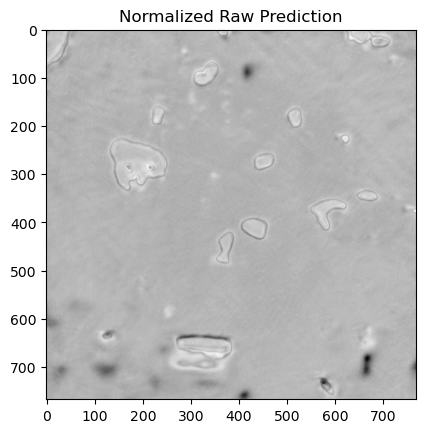

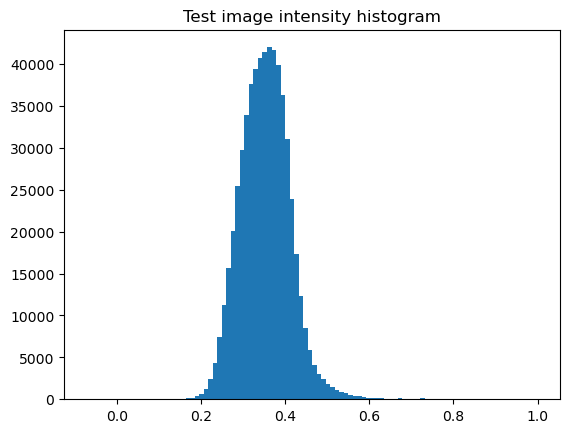

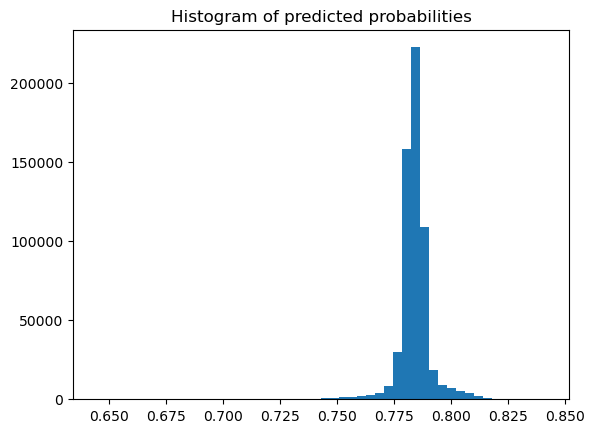

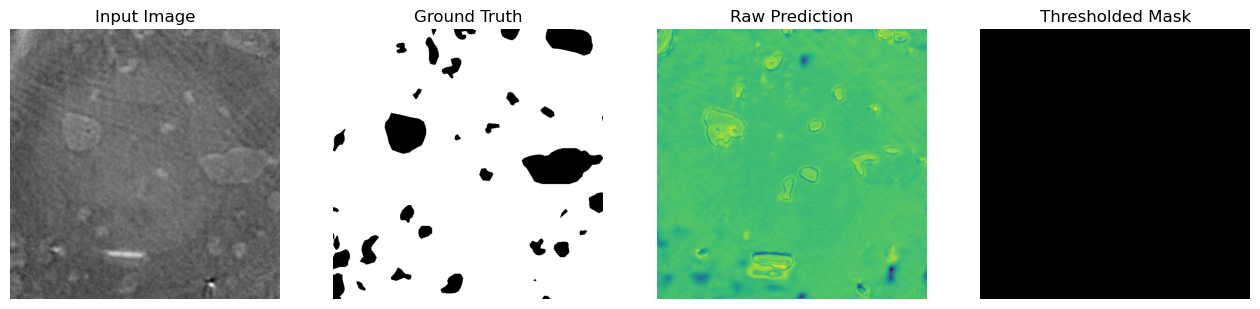

Saved prediction and ground truth for image 0 ✔


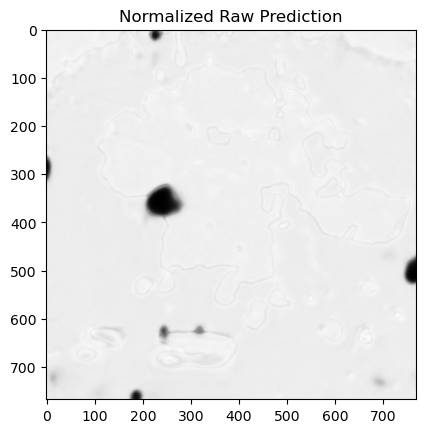

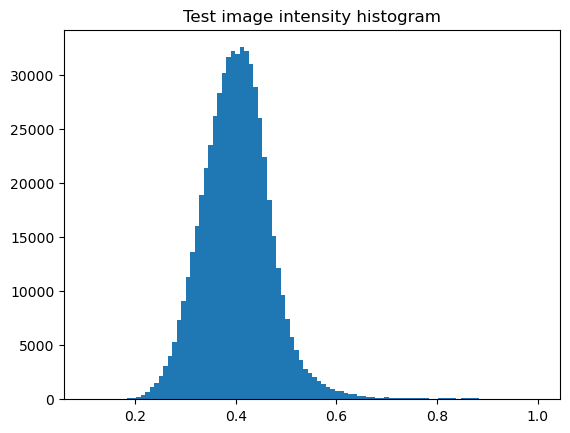

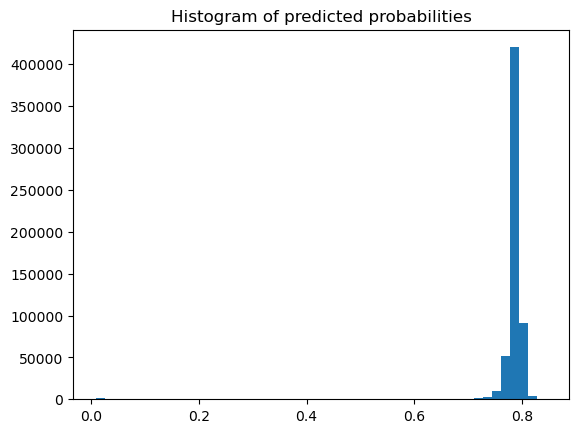

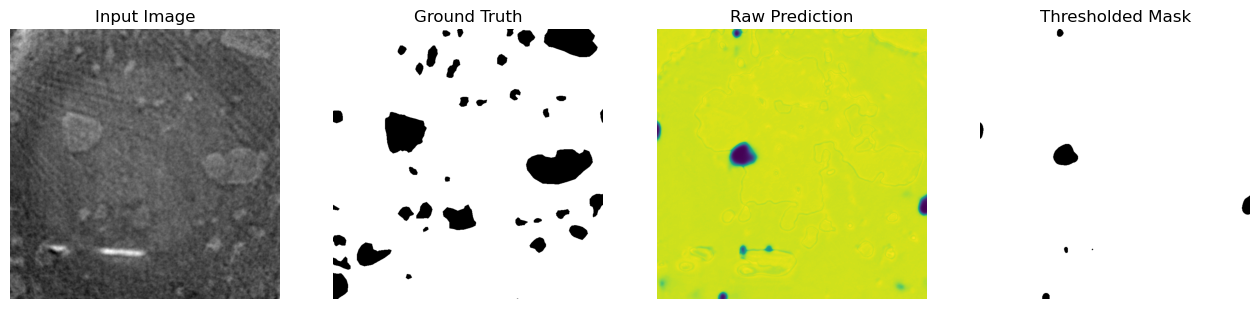

Saved prediction and ground truth for image 1 ✔


In [47]:
# -----------------------
# Inference & Display (Fixed)
# -----------------------
import torch.nn.functional as F

save_dir = "./models/predicted_models/predictions/test"
os.makedirs(save_dir, exist_ok=True)

with torch.no_grad():
    for i in range(2):  # first 2 images
        img, mask = test_ds[i]
        img_batch = img.unsqueeze(0).to(device)  # [1,1,H,W]
        
        # Model prediction
        pred_logits = model(img_batch)
        pred_sigmoid = torch.sigmoid(pred_logits).cpu()
        
        # Resize prediction to match original mask
        pred_sigmoid_resized = F.interpolate(pred_sigmoid, size=mask.shape[-2:], mode='bilinear', align_corners=False)
        # pred_mask = (pred_sigmoid_resized > 0.01).float()  # low threshold
        threshold = 0.5 * pred_sigmoid_resized.max()
        pred_mask = (pred_sigmoid_resized > threshold).float()

        # Save predictions
        pred_path = os.path.join(save_dir, f"pred_{i}.tif")
        gt_path = os.path.join(save_dir, f"gt_{i}.tif")
        tiff.imwrite(pred_path, pred_mask.squeeze().numpy())
        tiff.imwrite(gt_path, mask.squeeze().numpy())
        
        # Display normalized raw prediction for visualization
        pred_norm = (pred_sigmoid_resized - pred_sigmoid_resized.min()) / \
                    (pred_sigmoid_resized.max() - pred_sigmoid_resized.min() + 1e-8)
        plt.imshow(pred_norm.squeeze().numpy(), cmap='gray')
        plt.title("Normalized Raw Prediction")
        plt.show()
        
        plt.hist(img.squeeze().numpy().flatten(), bins=100)
        plt.title("Test image intensity histogram")
        plt.show()

        plt.hist(pred_sigmoid_resized.squeeze().numpy().flatten(), bins=50)
        plt.title("Histogram of predicted probabilities")
        plt.show()  

        # Display input, GT, raw prediction, thresholded mask
        fig, axes = plt.subplots(1,4, figsize=(16,4))
        axes[0].imshow(img.squeeze().numpy(), cmap='gray')
        axes[0].set_title("Input Image")
        axes[1].imshow(mask.squeeze().numpy(), cmap='gray')
        axes[1].set_title("Ground Truth")
        axes[2].imshow(pred_sigmoid_resized.squeeze().numpy(), cmap='viridis')
        axes[2].set_title("Raw Prediction")
        axes[3].imshow(pred_mask.squeeze().numpy(), cmap='gray')
        axes[3].set_title("Thresholded Mask")
        for ax in axes:
            ax.axis('off')
        plt.show()
        
        print(f"Saved prediction and ground truth for image {i} ✔")